In [11]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from keras import regularizers
from keras import initializers

# =========================
# CONFIG
# =========================
TS = 0.07
TIME_STEPS = 15
BATCH_SIZE = 32

DATA_PATH = "./Data/Datasets.xlsx"

TARGET = "Theta"
PREDICTORS = ["PwmD", "PwmE", "sPwm", "dPwm"]

INPUT_SIZE = len(PREDICTORS)  
OUTPUT_SIZE = 1 

TITLES = ["Train_1", "Train_2", "Val_1", "Val_2", "Test_1", "Test_2", "LSG_1", "LSG_2"]


In [12]:
# =========================
# SLIDING WINDOW
# =========================
def create_sequences(pred, target, time_steps):
    Xs, ys = [], []
    for i in range(len(pred) - time_steps):
        Xs.append(pred[i:i+time_steps])
        ys.append(target[i+time_steps])
    return np.array(Xs), np.array(ys)

# =========================
# LOAD TREINO
# =========================
df_train = pd.concat([
    pd.read_excel(DATA_PATH, sheet_name="Train_1"),
    pd.read_excel(DATA_PATH, sheet_name="Train_2")
])

Out_train = df_train[TARGET].values
dOut_train = df_train[f"d{TARGET}"].values

Inp_train = df_train[PREDICTORS].values

# =========================
# LOAD VAL
# =========================
df_val = pd.concat([
    pd.read_excel(DATA_PATH, sheet_name="Val_1"),
    pd.read_excel(DATA_PATH, sheet_name="Val_2")
])

dOut_val = df_val[f"d{TARGET}"].values
Inp_val = df_val[PREDICTORS].values


# =========================
# LOAD Physics
# =========================
Theta = df_train["Theta"].values
Wd = df_train["Wd"].values
We = df_train["We"].values

# =========================
# NORMALIZAÇÃO 
# =========================
InpScaler = StandardScaler()
OutScaler = StandardScaler()

Inp_train = InpScaler.fit_transform(Inp_train)
dOut_train = OutScaler.fit_transform(dOut_train.reshape(-1, 1)).flatten()

Inp_val = InpScaler.transform(Inp_val)
dOut_val  = OutScaler.transform(dOut_val.reshape(-1, 1)).flatten()

# =========================
# Sequencias 
# =========================
Inp_train, dOut_train = create_sequences(Inp_train, dOut_train, TIME_STEPS)
Inp_val, dOut_val = create_sequences(Inp_val, dOut_val, TIME_STEPS)

Wd_p, _     = create_sequences(Wd, Wd, TIME_STEPS)
We_p, _     = create_sequences(We, We, TIME_STEPS)
Theta_p, _  = create_sequences(Theta, Theta, TIME_STEPS)


In [13]:
print("=== SHAPES APÓS SEQUÊNCIAS ===")

print("Inp_val:", Inp_val.shape)
print("dOut_val:", dOut_val.shape)

print("Inp_train:", Inp_train.shape)
print("dOut_train:", dOut_train.shape)
print("Wd_p:", Wd_p.shape)
print("We_p:", We_p.shape)
print("Theta_p:", Theta_p.shape)

=== SHAPES APÓS SEQUÊNCIAS ===
Inp_val: (1947, 15, 4)
dOut_val: (1947,)
Inp_train: (1935, 15, 4)
dOut_train: (1935,)
Wd_p: (1935, 15)
We_p: (1935, 15)
Theta_p: (1935, 15)


In [20]:
mean_tf = tf.constant(OutScaler.mean_[0], dtype=tf.float32)
std_tf  = tf.constant(OutScaler.scale_[0], dtype=tf.float32) 
 
Inp_val = tf.convert_to_tensor(Inp_val, dtype=tf.float32)
dOut_val = tf.convert_to_tensor(dOut_val, dtype=tf.float32)

Inp_train = tf.convert_to_tensor(Inp_train, dtype=tf.float32)
dOut_train = tf.convert_to_tensor(dOut_train, dtype=tf.float32)

Wd_p = tf.convert_to_tensor(Wd_p, dtype=tf.float32)
We_p = tf.convert_to_tensor(We_p, dtype=tf.float32)
Theta_p = tf.convert_to_tensor(Theta_p, dtype=tf.float32)


In [21]:
# =========================
# MODELO 
# =========================
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

initializer = tf.keras.initializers.GlorotUniform(seed=SEED)
recurrent_initializer = tf.keras.initializers.Orthogonal(seed=SEED)

l2_reg = tf.keras.regularizers.l2(1e-4)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(TIME_STEPS, INPUT_SIZE)),
    
    tf.keras.layers.SimpleRNN(
        32,
        activation='tanh',
        kernel_initializer=initializer,
        recurrent_initializer=recurrent_initializer,
        bias_initializer='zeros',
        kernel_regularizer=l2_reg,
        recurrent_regularizer=l2_reg
    ),
    
    tf.keras.layers.Dense(
        OUTPUT_SIZE,
        activation='linear',
        kernel_initializer=initializer,
        bias_initializer='zeros',
        kernel_regularizer=l2_reg
    )
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='mse'
)

In [35]:
# =========================
# TRAIN STEP
# =========================
R = tf.constant(0.0328, dtype=tf.float32)
L = tf.constant(0.0615, dtype=tf.float32)
dt = tf.constant(TS, dtype=tf.float32)

def CinematicModel(Wd, We, theta):
    if TARGET == "Theta": 
        return (R / (2 * L)) * (Wd - We)
    if TARGET == "X": 
        return (R / 2) * tf.cos(theta) * (Wd + We)
    if TARGET == "Y": 
        return (R / 2) * tf.sin(theta) * (Wd + We)

@tf.function
def train_step(model, optimizer, Inp, dOut, dOutCin, Ld, Lp):
    alpha = 3.0
    weights = 1 + alpha * tf.abs(dOut)

    with tf.GradientTape() as tape:
        # FeedForward
        dOut_pred = model(Inp, training=True)
        # Data Loss
        data_loss = tf.reduce_mean(weights * tf.square(dOut_pred - dOut))
        # Physics Loss
        physics_loss = tf.reduce_mean(tf.square(dOut_pred - dOutCin))

        loss = Ld * data_loss + Lp * physics_loss

    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    return data_loss, physics_loss

In [36]:

def EarlyStopping(model, best_loss, counter, best_weights, min_delta=1e-3):
    dOut_val_pred = model(Inp_val, training=False)
    val_loss = tf.reduce_mean(tf.square(dOut_val_pred - dOut_val))

    if val_loss < (best_loss - min_delta):
        best_loss = val_loss
        counter = 0
        best_weights = model.get_weights()
    else:
        counter += 1

    return best_loss, counter, best_weights, val_loss

def TrainPINN(model, optimizer, Ld, Lp, epochs, Es=False, patience=50):

    best_loss = np.inf
    counter = 0
    best_weights = model.get_weights()

    for epoch in range(epochs):

        loss_d_epoch = []
        loss_f_epoch = []

        for i in range(0, len(Inp_train), BATCH_SIZE):

            Inp_b = Inp_train[i:i+BATCH_SIZE]
            dOut_b = dOut_train[i:i+BATCH_SIZE]
            Theta_b = Theta_p[i:i+BATCH_SIZE]
            Wd_b = Wd_p[i:i+BATCH_SIZE]
            We_b = We_p[i:i+BATCH_SIZE]
        
            # Physics (último passo da sequência)
            dOutCin = CinematicModel(Wd_b[:, -1], We_b[:, -1], Theta_b[:, -1])
            dOutCin = tf.reshape(dOutCin, (-1, 1))
            dOutCin = OutScaler.transform(dOutCin)
        
            ld, lf = train_step(
                model,
                optimizer,
                tf.convert_to_tensor(Inp_b, tf.float32),
                tf.convert_to_tensor(tf.reshape(dOut_b, (-1, 1)), tf.float32),
                tf.convert_to_tensor(dOutCin, tf.float32),
                Ld, 
                Lp
            )

            loss_d_epoch.append(ld.numpy())
            loss_f_epoch.append(lf.numpy())

        if Es == True:
            best_loss, counter, best_weights, val_loss = EarlyStopping(
            model, best_loss, counter, best_weights)
            
            if epoch % 10 == 0:
                print(f"Epoch {epoch} | Ld={np.mean(loss_d_epoch):.4f} | "
                    f"Lf={np.mean(loss_f_epoch):.4f} | Val={val_loss.numpy():.6f}")

            if counter >= patience:
                print(f"\n⛔ Early stopping na época {epoch}")
                break
        else:
            print(f"Epoch {epoch+1} | Ld={np.mean(loss_d_epoch):.4f} | Lf={np.mean(loss_f_epoch):.4f}")

    if Es == True:
        model.set_weights(best_weights)

In [37]:
tf.keras.backend.clear_session()
model.build((None, TIME_STEPS, INPUT_SIZE))
opt = tf.keras.optimizers.Adam(1e-3)
opt.build(model.trainable_variables)

TrainPINN(model, 
          optimizer=opt,
          Ld = 0.5,
          Lp = 0.5,
          epochs=300,
          Es=True,
          patience=50)

Epoch 0 | Ld=0.7557 | Lf=0.1442 | Val=1.921072
Epoch 10 | Ld=0.4840 | Lf=0.1369 | Val=1.975903
Epoch 20 | Ld=0.4036 | Lf=0.1323 | Val=2.035199
Epoch 30 | Ld=0.4512 | Lf=0.1457 | Val=1.972639
Epoch 40 | Ld=0.6221 | Lf=0.1905 | Val=2.153836
Epoch 50 | Ld=0.4006 | Lf=0.1396 | Val=2.008361
Epoch 60 | Ld=0.4322 | Lf=0.1466 | Val=1.940312

⛔ Early stopping na época 62


Train_1 | R2 dOut_test: 0.8430 | R2 Out: 0.7936
Train_2 | R2 dOut_test: 0.8429 | R2 Out: 0.8429
Val_1 | R2 dOut_test: 0.6042 | R2 Out: -0.1355
Val_2 | R2 dOut_test: 0.8483 | R2 Out: -0.8655
Test_1 | R2 dOut_test: 0.0038 | R2 Out: -6.7753
Test_2 | R2 dOut_test: -0.1796 | R2 Out: -5.3736
LSG_1 | R2 dOut_test: 0.5624 | R2 Out: -0.1858
LSG_2 | R2 dOut_test: 0.6015 | R2 Out: -5.5526


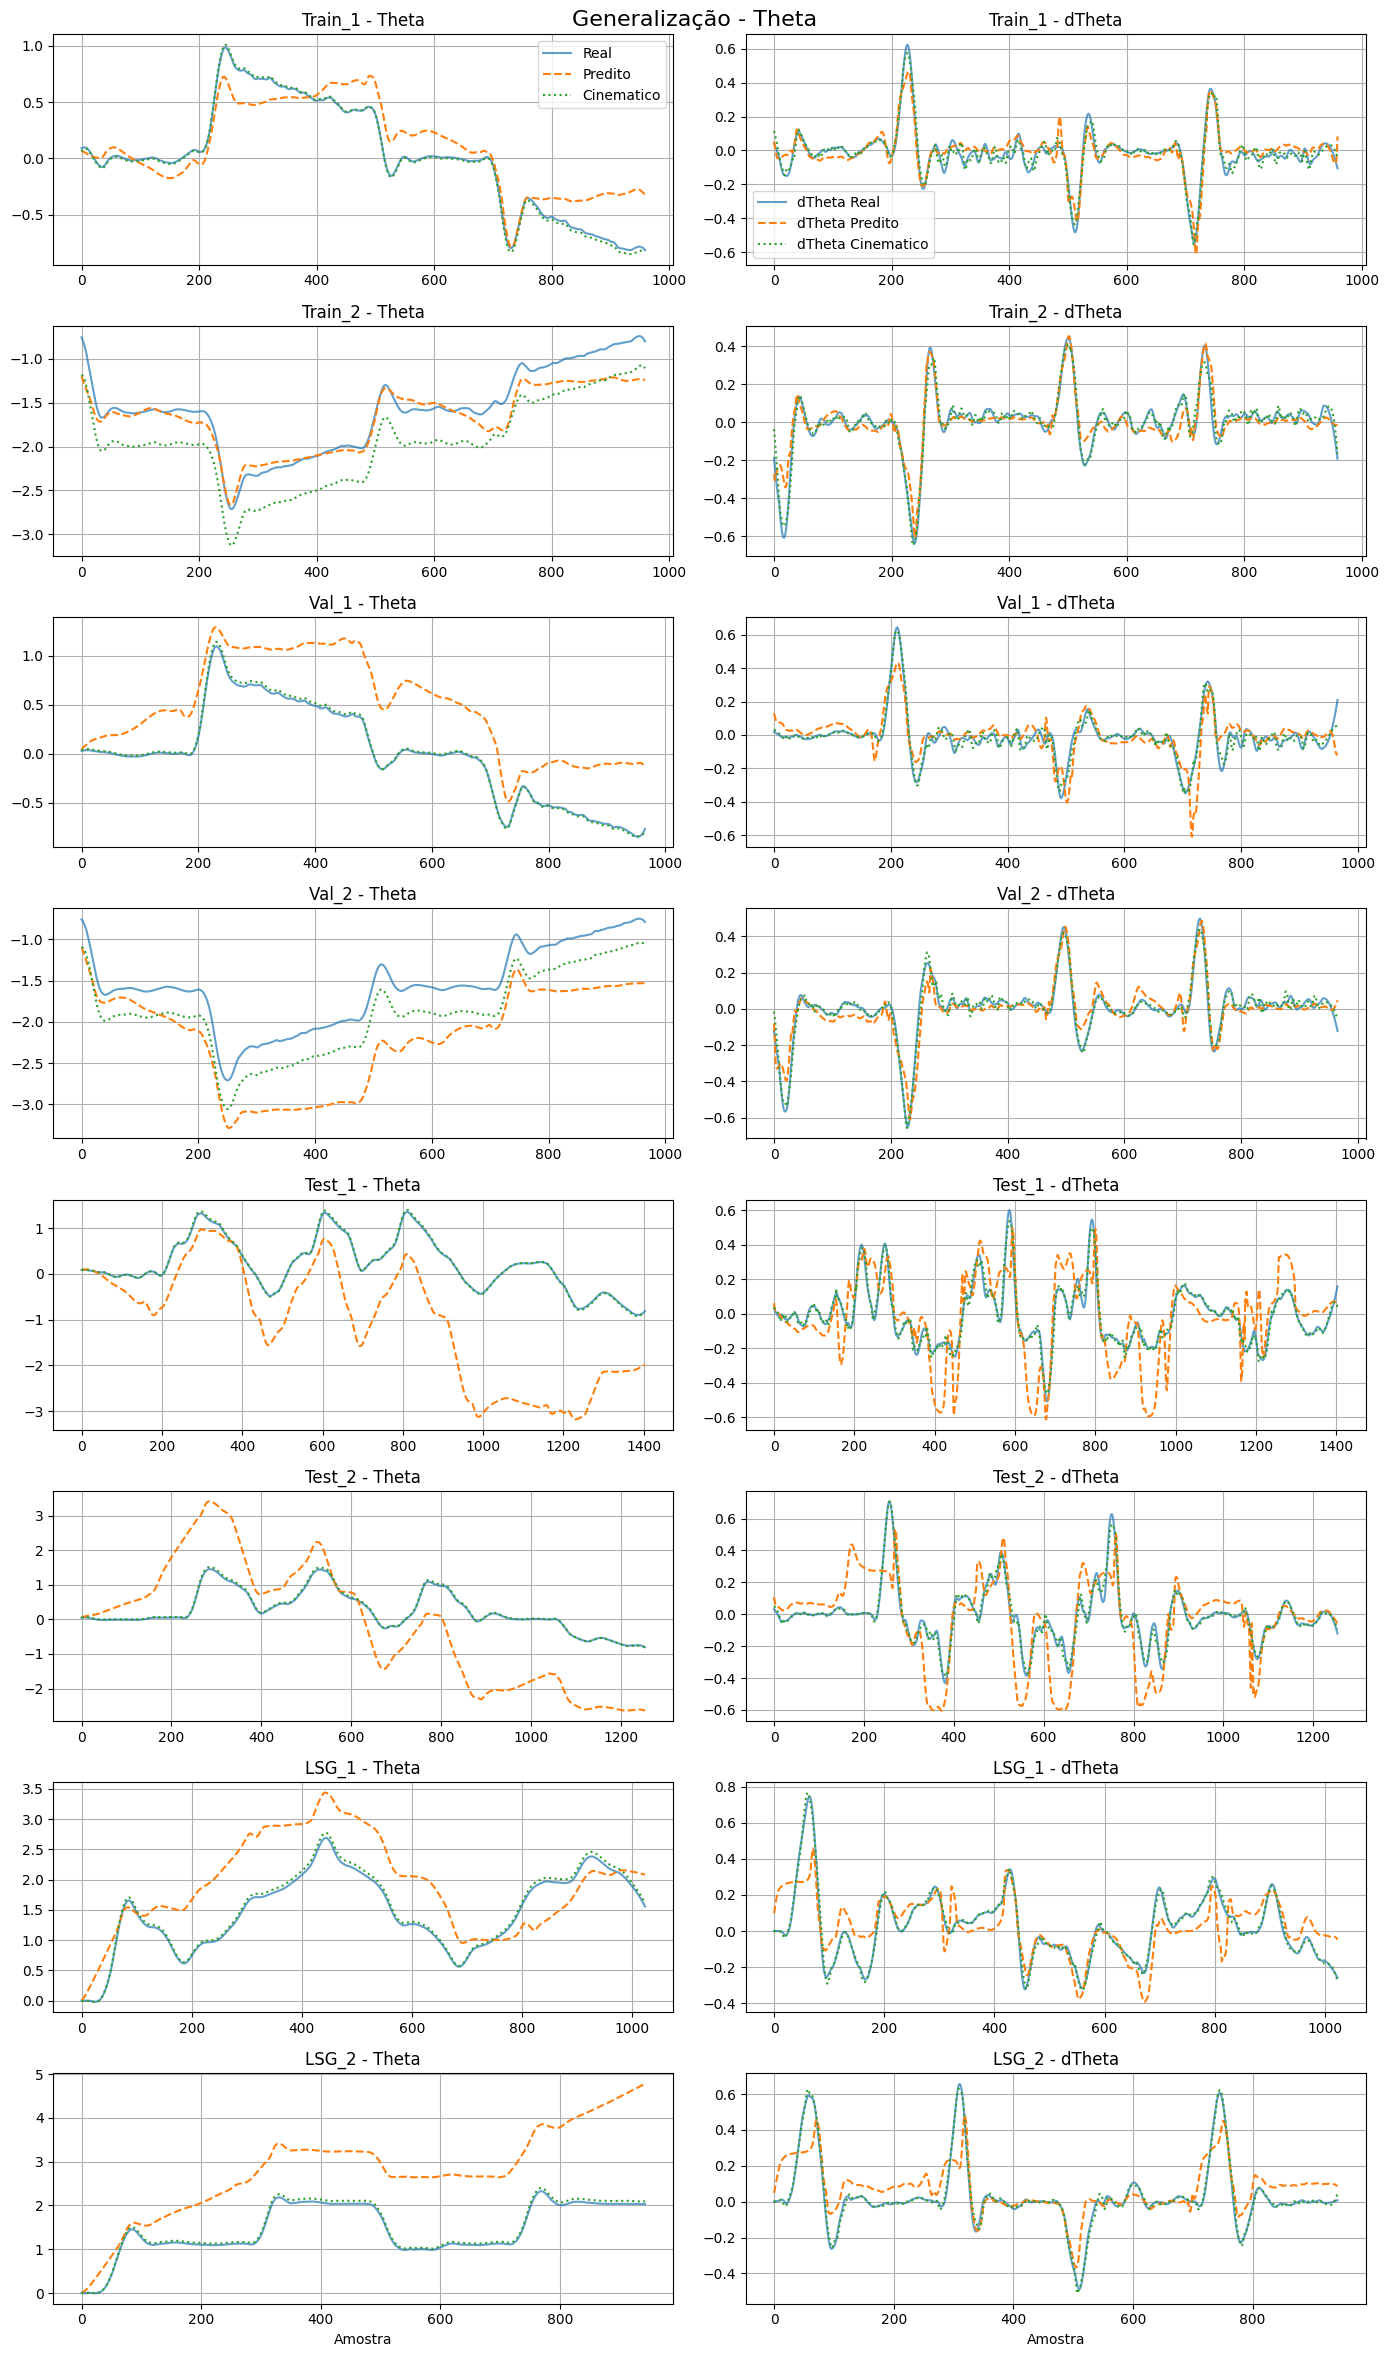

In [38]:
# =========================
# Teste
# =========================
n = len(TITLES)
fig, axs = plt.subplots(n, 2, figsize=(14, 3*n))

for i, title in enumerate(TITLES):

    df_test = pd.read_excel(DATA_PATH, sheet_name=title)

    Out_test_true = df_test[TARGET].values
    dOut_test_true = df_test[f"d{TARGET}"].values

    Inp_test = df_test[PREDICTORS].values

    Inp_test_scaled = InpScaler.transform(Inp_test)   
    Inp_test, Out_test_true = create_sequences(Inp_test_scaled, Out_test_true, TIME_STEPS)
    _, dOut_test_true = create_sequences(Inp_test_scaled, dOut_test_true, TIME_STEPS)
    
    # predição normalizada
    dOut_test_pred = model.predict(Inp_test, verbose=0)
    # predição desnormalizada
    dOut_test_pred = OutScaler.inverse_transform(dOut_test_pred)
    
    # Physics
    _,  Wd = create_sequences(Inp_test_scaled, df_test["Wd"].values.astype(np.float32), TIME_STEPS) 
    _,  We = create_sequences(Inp_test_scaled, df_test["We"].values.astype(np.float32), TIME_STEPS) 
    _,  Theta = create_sequences(Inp_test_scaled, df_test["Theta"].values.astype(np.float32), TIME_STEPS) 

    dOut_cin = CinematicModel(Wd, We, Theta).numpy()    
    # =========================
    # RECONSTRUÇÃO 
    # =========================
    Out_test_true_0 = Out_test_true[TIME_STEPS:][0]
    Out_test_pred = Out_test_true_0 + np.cumsum(dOut_test_pred.flatten() * TS)
    Out_cin = Out_test_true_0 + np.cumsum(dOut_cin.flatten() * TS)

    # =========================
    # PLOT TARGET
    # =========================
    axs[i, 0].plot(Out_test_true, label="Real", alpha=0.7)
    axs[i, 0].plot(Out_test_pred, label="Predito", linestyle='--')
    axs[i, 0].plot(Out_cin, label="Cinematico", linestyle=':')

    axs[i, 0].set_title(f"{title} - {TARGET}")
    axs[i, 0].grid(True)

    if i == 0:
        axs[i, 0].legend()

    # =========================
    # PLOT DERIVADA
    # =========================
    axs[i, 1].plot(dOut_test_true, label=f"d{TARGET} Real", alpha=0.7)
    axs[i, 1].plot(dOut_test_pred, label=f"d{TARGET} Predito", linestyle='--')
    axs[i, 1].plot(dOut_cin, label=f"d{TARGET} Cinematico", linestyle=':')

    axs[i, 1].set_title(f"{title} - d{TARGET}")
    axs[i, 1].grid(True)

    if i == 0:
        axs[i, 1].legend()
    r2_dOut_test = r2_score(dOut_test_true.flatten(), dOut_test_pred.flatten())
    r2_Out_test  = r2_score(Out_test_true.flatten(), Out_test_pred.flatten())
    print(f"{title} | R2 dOut_test: {r2_dOut_test:.4f} | R2 Out: {r2_Out_test:.4f}")

axs[-1, 0].set_xlabel("Amostra")
axs[-1, 1].set_xlabel("Amostra")

plt.suptitle(f"Generalização - {TARGET}", fontsize=16)
plt.tight_layout()
plt.show()